# S1.0: frozen synthetic benchmark плеврального скольжения

Этот notebook **не запускает и не настраивает регистрацию**. Он читает batch-артефакты,
созданные командой `breathgeom registration sliding-synthetic`, проверяет checksums и
визуализирует заранее зафиксированный algorithmic gate.

S1 получает только fixed/moving изображения и маски. Аналитические поля используются
только оценщиком после завершения регистрации. PASS здесь ещё не заменил бы реальные
Gate 1L/1B; FAIL блокирует real-pair benchmark и парные карты.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

candidate = Path.cwd().resolve()
REPO_ROOT = next(
    (path for path in (candidate, *candidate.parents) if (path / "pyproject.toml").is_file()),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Не найден корень репозитория")

RESULTS = REPO_ROOT / "results/sliding_s1_v0"
manifest_path = RESULTS / "manifest.json"
summary_path = RESULTS / "summary.csv"
if not manifest_path.is_file() or not summary_path.is_file():
    raise RuntimeError(
        "Нет batch-артефактов. Сначала выполните: "
        "breathgeom registration sliding-synthetic"
    )

## Provenance и целостность

Manifest фиксирует версии suite/S1, commit базового вычислительного кода, параметры gate
и SHA-256 каждого внешнего артефакта. В notebook не встраиваются локальные абсолютные пути.

In [2]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
assert sha256(summary_path) == manifest["summary_sha256"]
for filename, expected in manifest["field_sha256"].items():
    assert sha256(RESULTS / filename) == expected

provenance = pd.DataFrame(
    [
        {"Параметр": "suite_version", "Значение": manifest["suite_version"]},
        {"Параметр": "s1_version", "Значение": manifest["s1_version"]},
        {"Параметр": "code_version", "Значение": manifest["code_version"]},
        {"Параметр": "suite_sha256", "Значение": manifest["suite_config"]["sha256"]},
        {"Параметр": "s1_config_sha256", "Значение": manifest["s1_config"]["sha256"]},
        {"Параметр": "artifact_usage", "Значение": manifest["usage"]},
        {"Параметр": "checksum_verdict", "Значение": "PASS"},
    ]
)
display(provenance)

,Параметр,Значение
0,suite_version,sliding-phantom-v2.0
1,s1_version,s1.0
2,code_version,3ad78babee39edc04a9e5f8ad79a64a9e9297fff
3,suite_sha256,282040CD541CDE9177411F1DBAC045626C586E50F639DE...
4,s1_config_sha256,D4AD389C19803FC3158EFAA6C1A7B35890E524581A4DCD...
5,artifact_usage,synthetic_diagnostic_ONLY
6,checksum_verdict,PASS


## Subject-level результаты frozen suite

Единица решения — один synthetic case, не воксель. Полный gate требует одновременного
прохождения endpoint error лёгкого и стенки, normal contact, slip и regional topology.

In [3]:
summary = pd.read_csv(summary_path)
summary["gate_reasons"] = summary["gate_reasons"].fillna("")
columns = [
    "case_id",
    "spacing_mm",
    "normal_motion_truth_mm",
    "tangential_slip_truth_mm",
    "endpoint_p95_limit_mm",
    "lung_field_p95_mm",
    "body_field_p95_mm",
    "normal_mismatch_p95_mm",
    "tangential_slip_median_mm",
    "lung_jacobian_p01",
    "body_jacobian_p01",
    "gate_pass",
    "gate_reasons",
]
display(summary[columns].round(3))

gate_matrix = pd.DataFrame(
    {
        "lung field": summary["lung_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "body field": summary["body_field_p95_mm"] <= summary["endpoint_p95_limit_mm"],
        "normal contact": summary["normal_mismatch_p95_mm"]
        <= manifest["gate"]["normal_mismatch_p95_max_mm"],
        "tangential slip": summary["tangential_slip_error_mm"]
        <= manifest["gate"]["tangential_slip_error_max_mm"],
        "lung topology": (
            (summary["lung_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["lung_nonpositive_jacobian_fraction"] == 0)
        ),
        "body topology": (
            (summary["body_jacobian_p01"] >= manifest["gate"]["jacobian_p01_min"])
            & (summary["body_nonpositive_jacobian_fraction"] == 0)
        ),
    },
    index=summary["case_id"],
)
display(gate_matrix)

,case_id,spacing_mm,normal_motion_truth_mm,tangential_slip_truth_mm,endpoint_p95_limit_mm,lung_field_p95_mm,body_field_p95_mm,normal_mismatch_p95_mm,tangential_slip_median_mm,lung_jacobian_p01,body_jacobian_p01,gate_pass,gate_reasons
0,nominal_1mm,1.0x1.0x1.0,3.0,4.0,1.50,1.587,0.784,0.070,3.706,0.825,0.853,False,lung_field_p95
1,shallow_1mm,1.0x1.0x1.0,1.5,2.0,1.50,1.146,0.762,0.042,2.055,0.717,0.913,True,
2,deep_anisotropic,1.25x1.25x1.5,4.5,6.0,2.25,4.138,1.203,0.245,4.002,1.109,0.869,False,lung_field_p95;tangential_slip


,lung field,body field,normal contact,tangential slip,lung topology,body topology
case_id,,,,,,
nominal_1mm,NaN,NaN,NaN,NaN,NaN,NaN
shallow_1mm,NaN,NaN,NaN,NaN,NaN,NaN
deep_anisotropic,NaN,NaN,NaN,NaN,NaN,NaN


## Где именно S1.0 проходит и проваливается

Порог endpoint зависит от максимального размера вокселя. Slip сравнивается с известной
амплитудой каждого случая. Отдельно показан эффект normal-only coupling.

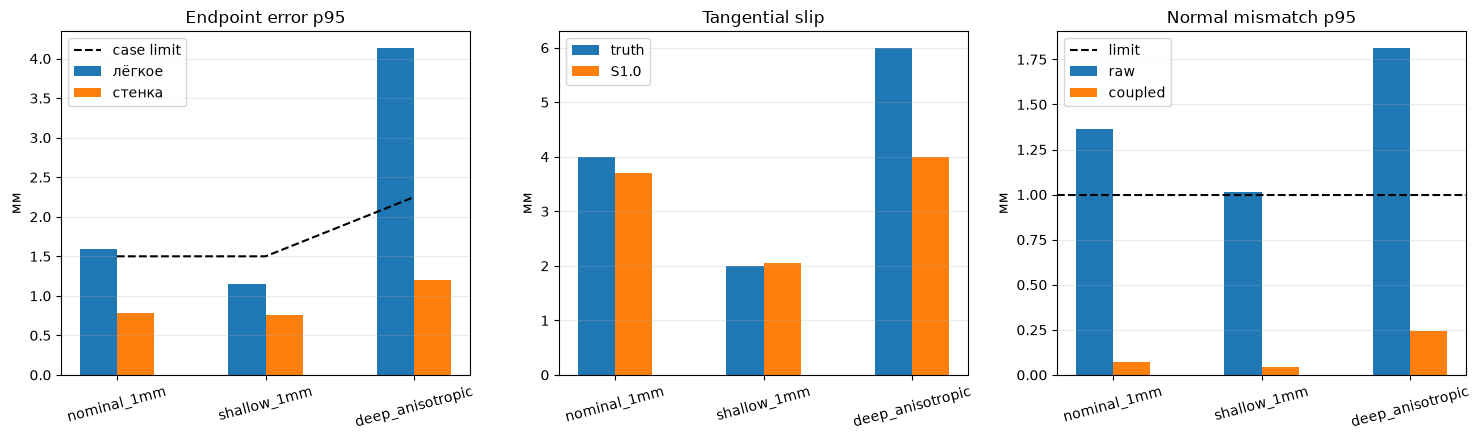

In [4]:
labels = summary["case_id"].tolist()
x = np.arange(len(summary))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].bar(x - width / 2, summary["lung_field_p95_mm"], width, label="лёгкое")
axes[0].bar(x + width / 2, summary["body_field_p95_mm"], width, label="стенка")
axes[0].plot(x, summary["endpoint_p95_limit_mm"], "k--", label="case limit")
axes[0].set_title("Endpoint error p95")
axes[0].set_ylabel("мм")
axes[0].legend()

axes[1].bar(x - width / 2, summary["tangential_slip_truth_mm"], width, label="truth")
axes[1].bar(x + width / 2, summary["tangential_slip_median_mm"], width, label="S1.0")
axes[1].set_title("Tangential slip")
axes[1].set_ylabel("мм")
axes[1].legend()

axes[2].bar(x - width / 2, summary["raw_normal_mismatch_p95_mm"], width, label="raw")
axes[2].bar(x + width / 2, summary["normal_mismatch_p95_mm"], width, label="coupled")
axes[2].axhline(
    manifest["gate"]["normal_mismatch_p95_max_mm"],
    color="black",
    linestyle="--",
    label="limit",
)
axes[2].set_title("Normal mismatch p95")
axes[2].set_ylabel("мм")
axes[2].legend()

for ax in axes:
    ax.set_xticks(x, labels, rotation=15)
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Пространственная локализация ошибки

Карты ниже показывают ошибку вектора, а не intensity residual. Цветовая шкала одинакова
для truth/estimate сравнения внутри каждого случая. Данные полностью synthetic.

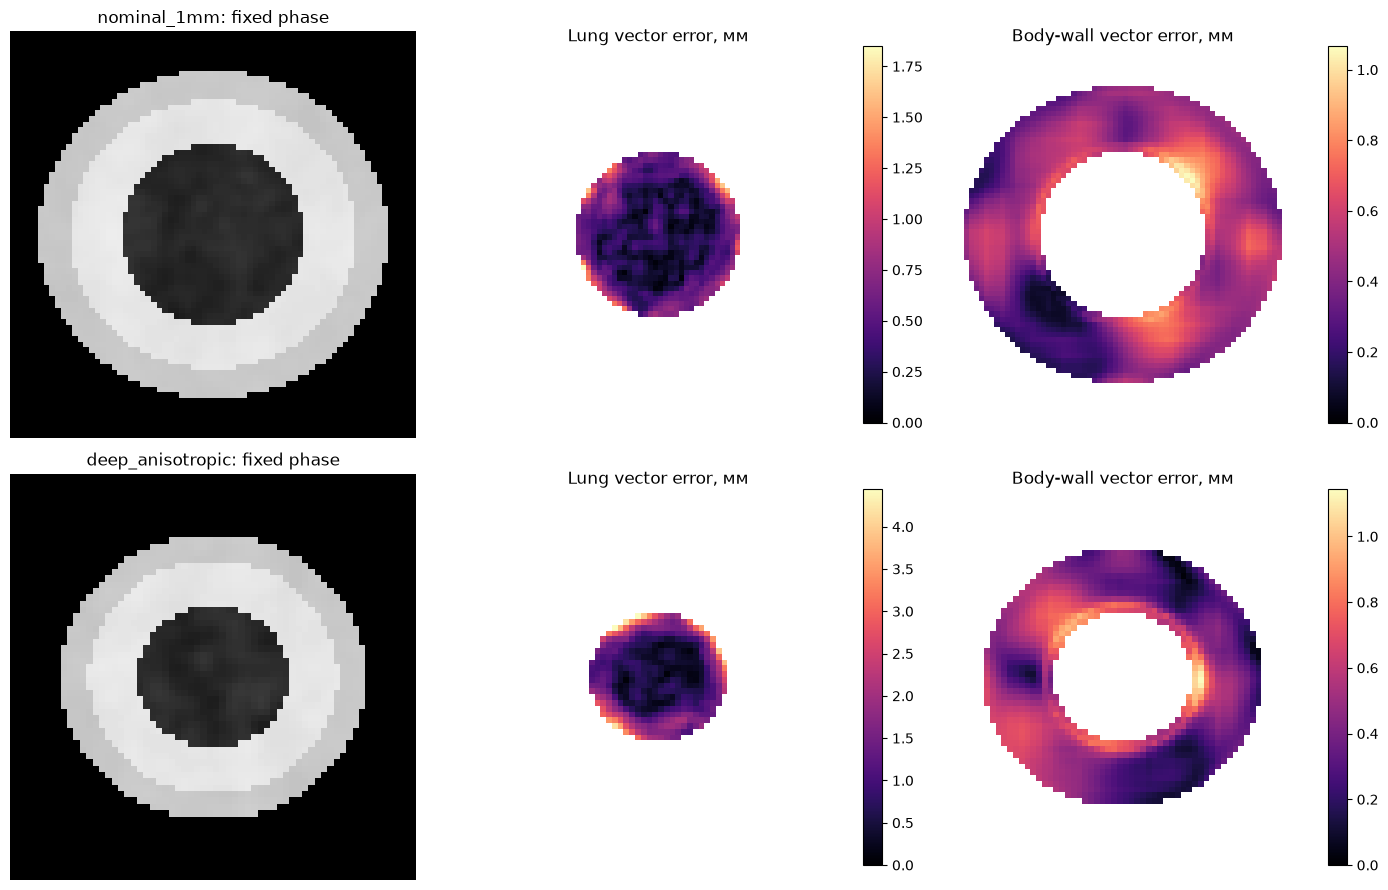

In [5]:
selected_cases = ["nominal_1mm", "deep_anisotropic"]
fig, axes = plt.subplots(len(selected_cases), 3, figsize=(14, 9))
for row, case_id in enumerate(selected_cases):
    with np.load(RESULTS / f"{case_id}.npz") as artifact:
        fixed = artifact["fixed_image"]
        lung_mask = artifact["fixed_lung_mask"].astype(bool)
        body_mask = artifact["fixed_body_mask"].astype(bool)
        lung_error = np.linalg.norm(
            artifact["estimated_lung_displacement_mm"]
            - artifact["truth_lung_displacement_mm"],
            axis=-1,
        )
        body_error = np.linalg.norm(
            artifact["estimated_body_displacement_mm"]
            - artifact["truth_body_displacement_mm"],
            axis=-1,
        )
    z_index = fixed.shape[2] // 2
    lung_slice = np.where(lung_mask[:, :, z_index], lung_error[:, :, z_index], np.nan).T
    wall = body_mask & ~lung_mask
    body_slice = np.where(wall[:, :, z_index], body_error[:, :, z_index], np.nan).T

    axes[row, 0].imshow(fixed[:, :, z_index].T, cmap="gray", origin="lower", vmin=-1000, vmax=150)
    axes[row, 0].set_title(f"{case_id}: fixed phase")
    im_lung = axes[row, 1].imshow(lung_slice, origin="lower", cmap="magma", vmin=0)
    axes[row, 1].set_title("Lung vector error, мм")
    fig.colorbar(im_lung, ax=axes[row, 1], fraction=0.046)
    im_body = axes[row, 2].imshow(body_slice, origin="lower", cmap="magma", vmin=0)
    axes[row, 2].set_title("Body-wall vector error, мм")
    fig.colorbar(im_body, ax=axes[row, 2], fraction=0.046)
    for ax in axes[row]:
        ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
pass_count = int(summary["gate_pass"].sum())
case_count = len(summary)
if manifest["all_pass"]:
    verdict = (
        f"## Итог: algorithmic synthetic gate PASS ({pass_count}/{case_count})\n\n"
        "S1.0 можно заморозить и перенести на development real pairs; реальные Gate 1L/1B "
        "всё ещё обязательны."
    )
else:
    failures = summary.loc[~summary["gate_pass"], ["case_id", "gate_reasons"]]
    failure_text = "; ".join(
        f"{row.case_id}: {row.gate_reasons}" for row in failures.itertuples()
    )
    verdict = (
        f"## Итог: algorithmic synthetic gate FAIL ({pass_count}/{case_count})\n\n"
        f"Провалы: {failure_text}.\n\n"
        "**Real-pair regression benchmark, карты формы лёгких и карты толщины остаются "
        "заблокированы.** Следующий кандидат должен улучшить внутреннее tangential lung field, "
        "не ухудшая уже прошедшие body/contact/topology проверки."
    )
display(Markdown(verdict))

## Итог: algorithmic synthetic gate FAIL (1/3)

Провалы: nominal_1mm: lung_field_p95; deep_anisotropic: lung_field_p95;tangential_slip.

**Real-pair regression benchmark, карты формы лёгких и карты толщины остаются заблокированы.** Следующий кандидат должен улучшить внутреннее tangential lung field, не ухудшая уже прошедшие body/contact/topology проверки.